# 01 — Data exploration with yfinance

We pull *daily* OHLCV for the full Lumina universe (yfinance is rate-limited
and only serves 1-minute bars for the last 7 days). Daily is enough for the
Phase-1 milestones; the agent is re-trained on minute data later.

**What this notebook now covers** (beyond a basic OHLCV dump):

* Calendar-aware loading — equities trade 5 days/week, crypto 7 — so coverage
  and missing-data are audited *per calendar*, not against a single expectation.
* Universe-wide return **moments** (skew / kurtosis / annualised vol & Sharpe /
  Jarque–Bera) for all 53 names, ranked by tail-heaviness.
* The two stylised facts a sequence model must respect: **volatility
  clustering** (ACF of squared returns + Ljung–Box) and **non-stationarity**
  (rolling moments + variance-ratio test).
* **Drawdowns**, **GMM volatility-regime** labelling, **contagion** (rolling
  cross-sectional correlation vs. market drawdown), **PCA factor structure**,
  and **liquidity** (dollar-volume + Amihud illiquidity).

Everything is cached to `notebooks/.cache/` on first run, so re-execution is
deterministic and offline.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from backend.config.constants import SECTORS, TARGET_TICKERS, TICKER_TO_SECTOR

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Plotting style ───────────────────────────────────────────────────────────
plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
    "accent": "#ab47bc",
}
SECTOR_PALETTE = dict(zip(SECTORS, plt.colormaps.get_cmap("tab10").colors))

# ── Project-root resolution (so the notebook runs from anywhere) ─────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
REPORTS = PROJECT_ROOT / "reports"
CACHE = PROJECT_ROOT / "notebooks" / ".cache"
REPORTS.mkdir(exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)


def cached(key: str, fn):
    """Memoise a DataFrame to notebooks/.cache/<key>.pkl (offline re-runs)."""
    path = CACHE / f"{key}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    obj = fn()
    obj.to_pickle(path)
    return obj


# ── Lightweight time-series statistics (numpy/scipy only) ────────────────────
def acf(x: np.ndarray, nlags: int) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = (x * x).sum()
    out = [1.0]
    for k in range(1, nlags + 1):
        out.append(float((x[:-k] * x[k:]).sum() / denom))
    return np.array(out)


def ljung_box(x: np.ndarray, lags: int) -> tuple[float, float]:
    n = len(x)
    a = acf(x, lags)[1:]
    q = n * (n + 2) * np.sum(a**2 / (n - np.arange(1, lags + 1)))
    return float(q), float(stats.chi2.sf(q, lags))


def variance_ratio(returns: np.ndarray, q: int) -> float:
    """Lo–MacKinlay overlapping variance ratio. VR≈1 → random walk."""
    r = np.asarray(returns, dtype=float)
    n = len(r)
    mu = r.mean()
    var1 = ((r - mu) ** 2).sum() / (n - 1)
    rq = np.convolve(r, np.ones(q), "valid")  # rolling q-sums
    m = q * (n - q + 1) * (1.0 - q / n)
    varq = ((rq - q * mu) ** 2).sum() / m
    return float(varq / (q * var1))


def drawdown(equity: np.ndarray) -> np.ndarray:
    peak = np.maximum.accumulate(equity)
    return equity / peak - 1.0


print("Project root:", PROJECT_ROOT)

Project root: /home/pyros05/Escritorio/lumina_project


## 1. Universe & trading calendars

The 53-name universe mixes three calendar types. Treating them uniformly is the
classic mistake that makes a naive "NaN < 5%" check fail forever — crypto has
bars on weekends, equities do not.

In [2]:
UNIVERSE = sorted(TARGET_TICKERS)
CRYPTO = sorted(t for t in UNIVERSE if TICKER_TO_SECTOR.get(t) == "crypto")
INDICES = sorted(t for t in UNIVERSE if TICKER_TO_SECTOR.get(t) == "index")
EQUITIES = sorted(set(UNIVERSE) - set(CRYPTO))  # equities + indices: 5-day calendar

START, END = "2018-01-01", "2024-12-31"
print(f"Universe : {len(UNIVERSE)} tickers")
print(f"  equities/indices (5-day): {len(EQUITIES)}")
print(f"  crypto           (7-day): {len(CRYPTO)} -> {CRYPTO}")
print(f"Window   : {START} -> {END}")

Universe : 53 tickers
  equities/indices (5-day): 50
  crypto           (7-day): 3 -> ['BTC-USD', 'ETH-USD', 'SOL-USD']
Window   : 2018-01-01 -> 2024-12-31


## 2. Load OHLCV (cached)

In [3]:
def _download_daily():
    return yf.download(
        UNIVERSE, start=START, end=END, interval="1d",
        auto_adjust=False, progress=False, threads=True,
    )


raw = cached("daily_ohlcv_2018_2024", _download_daily)
close = raw["Close"]
volume = raw["Volume"]
returns = np.log(close / close.shift(1))

print("Raw shape :", raw.shape)
print("Fields    :", list(raw.columns.levels[0]))
print("Close mtx :", close.shape)

Raw shape : (2556, 318)
Fields    : ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Close mtx : (2556, 53)


## 3. Coverage / quality audit — per calendar

We compare each ticker's observed bar count to the expectation *for its own
calendar*. A 7-day asset is held to ~365·years bars; a 5-day asset to ~252·years.

Worst 8 coverage:
             sector calendar   obs  expected  coverage
SOL-USD      crypto       7d  1726      2554  0.675803
AAPL           tech       5d  1760      1763  0.998298
ADBE           tech       5d  1760      1763  0.998298
ABBV     healthcare       5d  1760      1763  0.998298
AMZN           tech       5d  1760      1763  0.998298
AVGO           tech       5d  1760      1763  0.998298
BAC      financials       5d  1760      1763  0.998298
AMD            tech       5d  1760      1763  0.998298


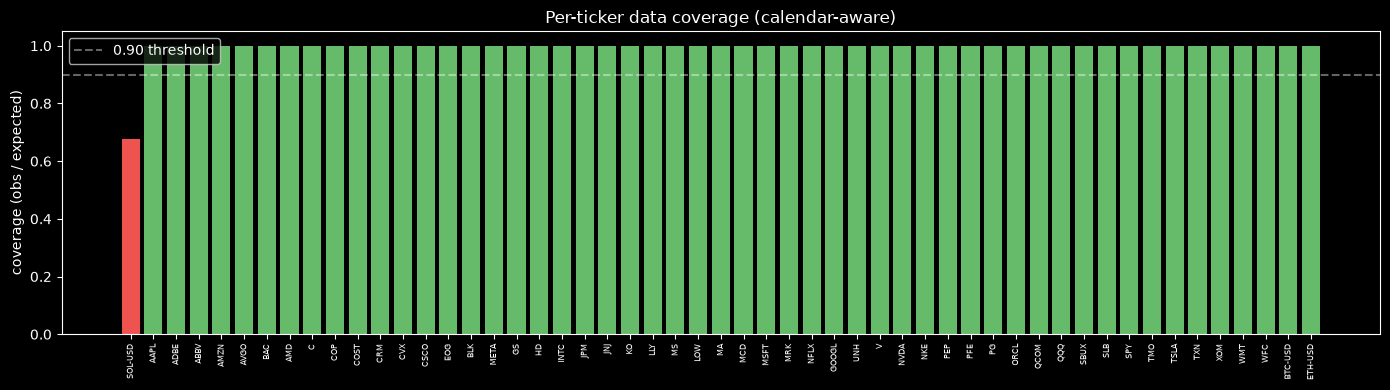

In [4]:
years = (pd.Timestamp(END) - pd.Timestamp(START)).days / 365.25
expected = {t: (365 if t in CRYPTO else 252) * years for t in UNIVERSE}

cov = pd.DataFrame({
    "sector": [TICKER_TO_SECTOR.get(t, "?") for t in UNIVERSE],
    "calendar": ["7d" if t in CRYPTO else "5d" for t in UNIVERSE],
    "obs": [int(close[t].notna().sum()) for t in UNIVERSE],
    "expected": [int(expected[t]) for t in UNIVERSE],
}, index=UNIVERSE)
cov["coverage"] = (cov["obs"] / cov["expected"]).clip(upper=1.0)

print("Worst 8 coverage:")
print(cov.sort_values("coverage").head(8).to_string())

fig, ax = plt.subplots(figsize=(14, 4))
order = cov.sort_values("coverage").index
ax.bar(range(len(order)), cov.loc[order, "coverage"],
       color=[COLORS["danger"] if c < 0.9 else COLORS["success"] for c in cov.loc[order, "coverage"]])
ax.axhline(0.9, color="white", ls="--", alpha=0.4, label="0.90 threshold")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90, fontsize=6)
ax.set_ylabel("coverage (obs / expected)")
ax.set_title("Per-ticker data coverage (calendar-aware)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Cumulative returns

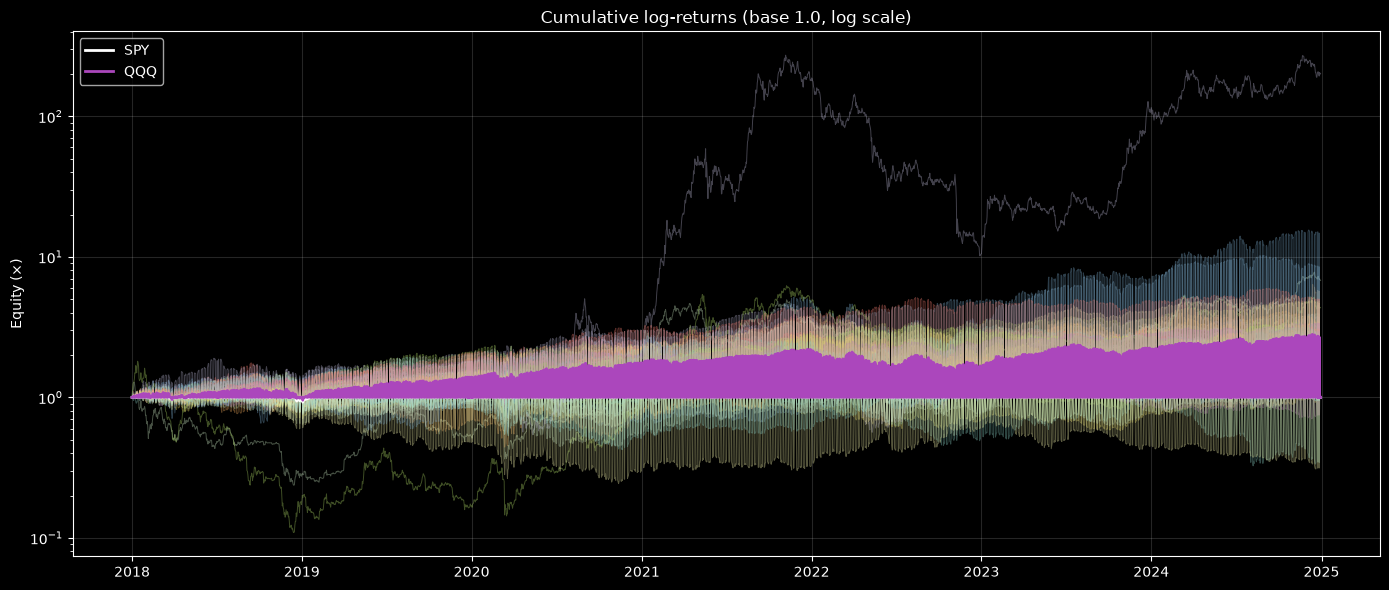

In [5]:
cum = returns.cumsum().fillna(0).apply(np.exp)
fig, ax = plt.subplots(figsize=(14, 6))
for col, c, w in [("SPY", "white", 2.0), ("QQQ", COLORS["accent"], 2.0)]:
    if col in cum.columns:
        ax.plot(cum.index, cum[col], color=c, linewidth=w, label=col, zorder=10)
for col in cum.columns:
    if col not in ("SPY", "QQQ"):
        ax.plot(cum.index, cum[col], alpha=0.35, linewidth=0.7)
ax.set_yscale("log")
ax.set_title("Cumulative log-returns (base 1.0, log scale)")
ax.set_ylabel("Equity (×)")
ax.grid(alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "01_cumulative_returns.png", dpi=120)
plt.show()

## 5. Universe-wide return moments

RL reward functions are sensitive to the return distribution. We tabulate the
first four moments plus annualised vol/Sharpe for *every* name (annualising
crypto with 365, equities with 252) and rank by excess kurtosis — the
fat-tail offenders that need robust normalisation downstream.

In [6]:
rows = []
for t in UNIVERSE:
    s = returns[t].dropna()
    if len(s) < 100:
        continue
    af = 365 if t in CRYPTO else 252
    jb_p = stats.jarque_bera(s)[1]
    rows.append({
        "ticker": t,
        "sector": TICKER_TO_SECTOR.get(t, "?"),
        "skew": s.skew(),
        "excess_kurt": s.kurtosis(),
        "ann_vol": s.std() * np.sqrt(af),
        "ann_sharpe": (s.mean() / s.std()) * np.sqrt(af),
        "jb_p": jb_p,
    })
moments = pd.DataFrame(rows).set_index("ticker")
moments["normal?"] = np.where(moments["jb_p"] > 0.05, "yes", "no")

print(f"Names failing Jarque-Bera normality (p<0.05): "
      f"{(moments['jb_p'] < 0.05).sum()} / {len(moments)}")
print("\nFattest tails (top 10 excess kurtosis):")
print(moments.sort_values("excess_kurt", ascending=False)
      .head(10)[["sector", "skew", "excess_kurt", "ann_vol", "ann_sharpe"]]
      .round(3).to_string())
moments.sort_values("excess_kurt", ascending=False).round(3)

Names failing Jarque-Bera normality (p<0.05): 53 / 53

Fattest tails (top 10 excess kurtosis):
                        sector   skew  excess_kurt  ann_vol  ann_sharpe
ticker                                                                 
NFLX                      tech -2.426       39.185    0.467       0.424
CVX                     energy -0.615       29.394    0.313      -0.022
META                      tech -1.407       26.532    0.437       0.438
MCD     consumer_discretionary  1.089       24.309    0.209       0.592
SBUX    consumer_discretionary  0.913       20.869    0.312       0.636
PEP           consumer_staples -0.185       20.818    0.206       0.298
INTC                      tech -1.302       17.854    0.415      -0.471
NKE     consumer_discretionary -0.740       17.172    0.332       0.425
ORCL                      tech  0.545       16.563    0.312       0.652
ABBV                healthcare -1.038       15.876    0.271       0.461


,sector,skew,excess_kurt,ann_vol,ann_sharpe,jb_p,normal?
ticker,,,,,,,
NFLX,tech,-2.426,39.185,0.467,0.424,0.0,no
CVX,energy,-0.615,29.394,0.313,-0.022,0.0,no
META,tech,-1.407,26.532,0.437,0.438,0.0,no
MCD,consumer_discretionary,1.089,24.309,0.209,0.592,0.0,no
SBUX,consumer_discretionary,0.913,20.869,0.312,0.636,0.0,no
PEP,consumer_staples,-0.185,20.818,0.206,0.298,0.0,no
INTC,tech,-1.302,17.854,0.415,-0.471,0.0,no
NKE,consumer_discretionary,-0.740,17.172,0.332,0.425,0.0,no
ORCL,tech,0.545,16.563,0.312,0.652,0.0,no


## 6. Fat tails — distribution & tail decay

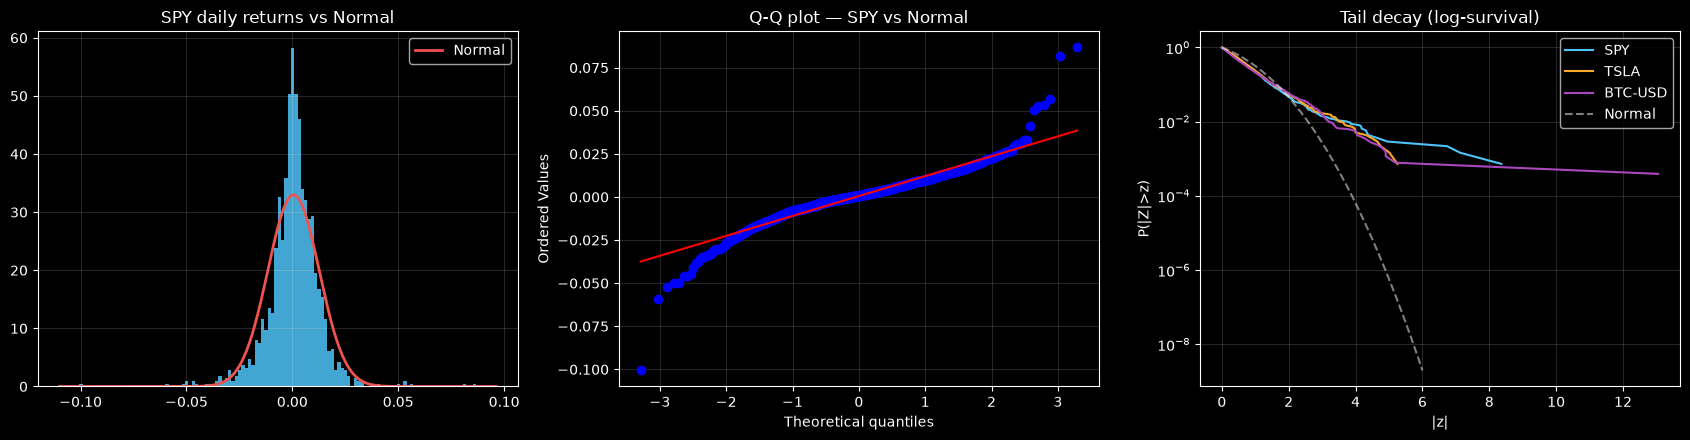

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

r = returns["SPY"].dropna()
axes[0].hist(r, bins=120, color=COLORS["primary"], alpha=0.85, density=True)
xs = np.linspace(*axes[0].get_xlim(), 300)
axes[0].plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color=COLORS["danger"], lw=2, label="Normal")
axes[0].set_title("SPY daily returns vs Normal"); axes[0].legend(); axes[0].grid(alpha=0.15)

stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot — SPY vs Normal"); axes[1].grid(alpha=0.15)

# Log-survival of |z| reveals tail decay; Normal is the dashed reference.
for t, c in [("SPY", COLORS["primary"]), ("TSLA", COLORS["warning"]), ("BTC-USD", COLORS["accent"])]:
    if t in returns:
        z = np.abs(stats.zscore(returns[t].dropna()))
        xs_ = np.sort(z)
        surv = 1.0 - np.arange(len(xs_)) / len(xs_)
        axes[2].semilogy(xs_, surv, label=t, color=c, lw=1.5)
zz = np.linspace(0, 6, 200)
axes[2].semilogy(zz, 2 * (1 - stats.norm.cdf(zz)), "w--", alpha=0.5, label="Normal")
axes[2].set_xlabel("|z|"); axes[2].set_ylabel("P(|Z|>z)")
axes[2].set_title("Tail decay (log-survival)"); axes[2].legend(); axes[2].grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 7. Volatility clustering — ACF & Ljung–Box

Returns are close to white noise; *squared* returns are strongly
autocorrelated. That gap is the volatility-clustering signature the TFT/LSTM
stack must capture. Ljung–Box on squared returns should reject white-noise
overwhelmingly.

Ljung-Box(20)  returns   : Q=    49.1  p=0.000301
Ljung-Box(20)  returns^2 : Q=  1687.1  p=0


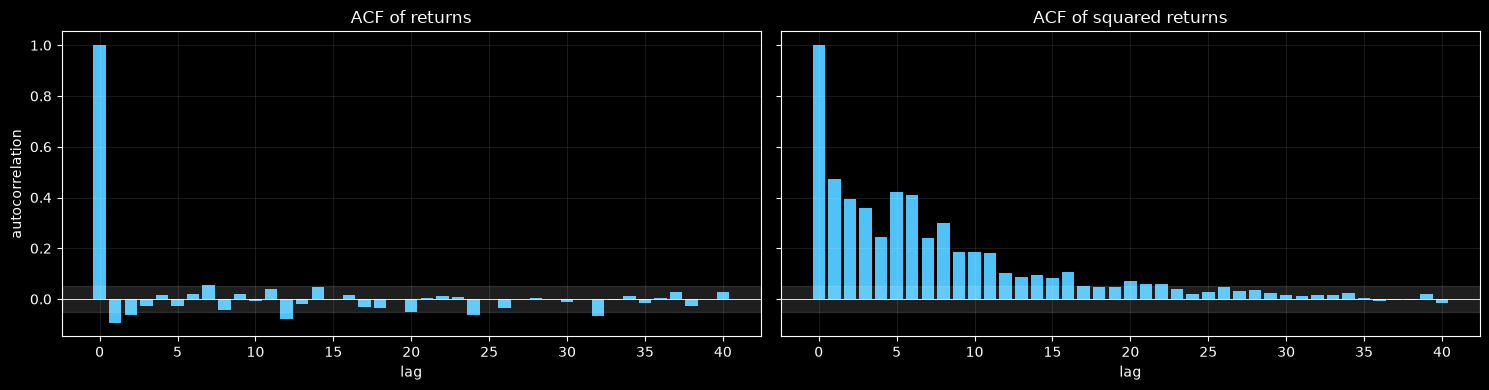

In [8]:
r = returns["SPY"].dropna().to_numpy()
LAGS = 40
acf_r = acf(r, LAGS)
acf_r2 = acf(r**2, LAGS)
conf = 1.96 / np.sqrt(len(r))

q_r, p_r = ljung_box(r, 20)
q_r2, p_r2 = ljung_box(r**2, 20)
print(f"Ljung-Box(20)  returns   : Q={q_r:8.1f}  p={p_r:.3g}")
print(f"Ljung-Box(20)  returns^2 : Q={q_r2:8.1f}  p={p_r2:.3g}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, a, title in [(axes[0], acf_r, "ACF of returns"),
                     (axes[1], acf_r2, "ACF of squared returns")]:
    ax.bar(range(LAGS + 1), a, color=COLORS["primary"], width=0.8)
    ax.axhspan(-conf, conf, color="white", alpha=0.12)
    ax.axhline(0, color="white", lw=0.6)
    ax.set_title(title); ax.set_xlabel("lag"); ax.grid(alpha=0.1)
axes[0].set_ylabel("autocorrelation")
plt.tight_layout()
plt.show()

## 8. Stationarity — rolling moments & variance ratio

Prices are non-stationary (random-walk-like); returns are approximately
stationary. The variance-ratio test quantifies it: VR(q)≈1 ⇒ random walk,
VR<1 ⇒ mean reversion, VR>1 ⇒ trending/momentum.

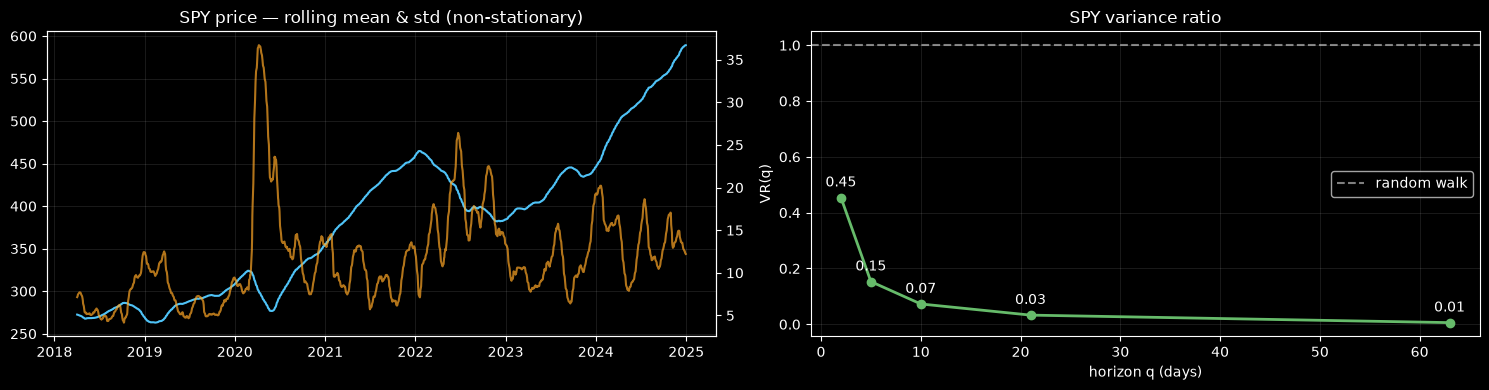

VR(q): {2: 0.454, 5: 0.153, 10: 0.073, 21: 0.033, 63: 0.006}


In [9]:
spy_px = close["SPY"].dropna()
spy_r = returns["SPY"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(spy_px.index, spy_px.rolling(63).mean(), color=COLORS["primary"], label="63d mean price")
ax0b = axes[0].twinx()
ax0b.plot(spy_px.index, spy_px.rolling(63).std(), color=COLORS["warning"], alpha=0.7, label="63d std")
axes[0].set_title("SPY price — rolling mean & std (non-stationary)")
axes[0].grid(alpha=0.1)

qs = [2, 5, 10, 21, 63]
vrs = [variance_ratio(spy_r.to_numpy(), q) for q in qs]
axes[1].axhline(1.0, color="white", ls="--", alpha=0.5, label="random walk")
axes[1].plot(qs, vrs, "o-", color=COLORS["success"], lw=2)
for q, v in zip(qs, vrs):
    axes[1].annotate(f"{v:.2f}", (q, v), textcoords="offset points", xytext=(0, 8), ha="center")
axes[1].set_xlabel("horizon q (days)"); axes[1].set_ylabel("VR(q)")
axes[1].set_title("SPY variance ratio"); axes[1].legend(); axes[1].grid(alpha=0.1)
plt.tight_layout()
plt.show()
print("VR(q):", {q: round(v, 3) for q, v in zip(qs, vrs)})

## 9. Volatility regimes — Gaussian mixture

A 2-component Gaussian mixture on log realised-vol cleanly separates a calm and
a stress regime — the kind of macro state the agent's uncertainty gate must
react to.

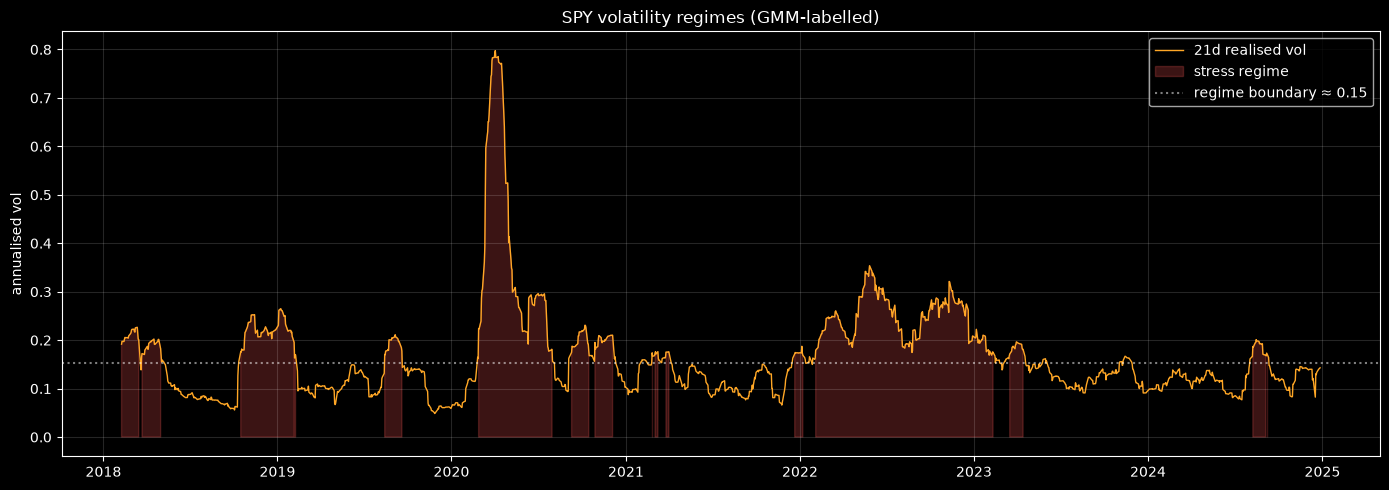

Stress days: 37.2% of sample | boundary vol ≈ 15.2%


In [10]:
rv = (spy_r.rolling(21).std() * np.sqrt(252)).dropna()
gmm = GaussianMixture(n_components=2, random_state=42).fit(np.log(rv).to_numpy().reshape(-1, 1))
state = gmm.predict(np.log(rv).to_numpy().reshape(-1, 1))
stress = state == int(np.argmax(gmm.means_.ravel()))  # higher-vol component
thresh = float(np.exp(np.mean(gmm.means_)))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rv.index, rv, color=COLORS["warning"], lw=1.0, label="21d realised vol")
ax.fill_between(rv.index, 0, rv, where=stress, color=COLORS["danger"], alpha=0.25, label="stress regime")
ax.axhline(thresh, color="white", ls=":", alpha=0.5, label=f"regime boundary ≈ {thresh:.2f}")
ax.set_title("SPY volatility regimes (GMM-labelled)")
ax.set_ylabel("annualised vol"); ax.legend(); ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()
print(f"Stress days: {stress.mean():.1%} of sample | boundary vol ≈ {thresh:.1%}")

## 10. Drawdowns

Maximum drawdown is the risk number the `max_drawdown_pct` kill-switch cares
about. We chart SPY's underwater curve and rank the universe by worst peak-to-
trough loss over the window.

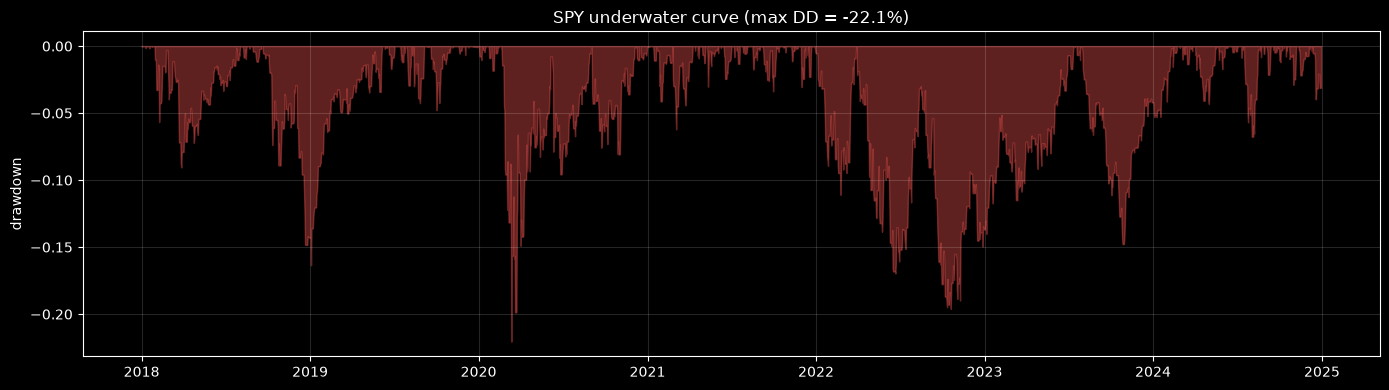

Deepest drawdowns:
SOL-USD    -98.6%
ETH-USD    -97.7%
BTC-USD    -86.6%
INTC       -84.2%
SLB        -82.9%
NFLX       -80.6%
TSLA       -78.9%
META       -77.4%


In [11]:
eq = (1 + returns["SPY"].fillna(0)).cumprod()
dd = drawdown(eq.to_numpy())

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(eq.index, dd, 0, color=COLORS["danger"], alpha=0.4)
ax.set_title(f"SPY underwater curve (max DD = {dd.min():.1%})")
ax.set_ylabel("drawdown"); ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

maxdd = {t: float(drawdown((1 + returns[t].fillna(0)).cumprod().to_numpy()).min())
         for t in UNIVERSE if returns[t].notna().sum() > 100}
maxdd = pd.Series(maxdd).sort_values()
print("Deepest drawdowns:")
print(maxdd.head(8).apply(lambda v: f"{v:.1%}").to_string())

## 11. Cross-asset correlation (sector-grouped)

Computed on the **equity calendar** (crypto excluded) so weekend NaNs don't
corrupt the pairwise estimates.

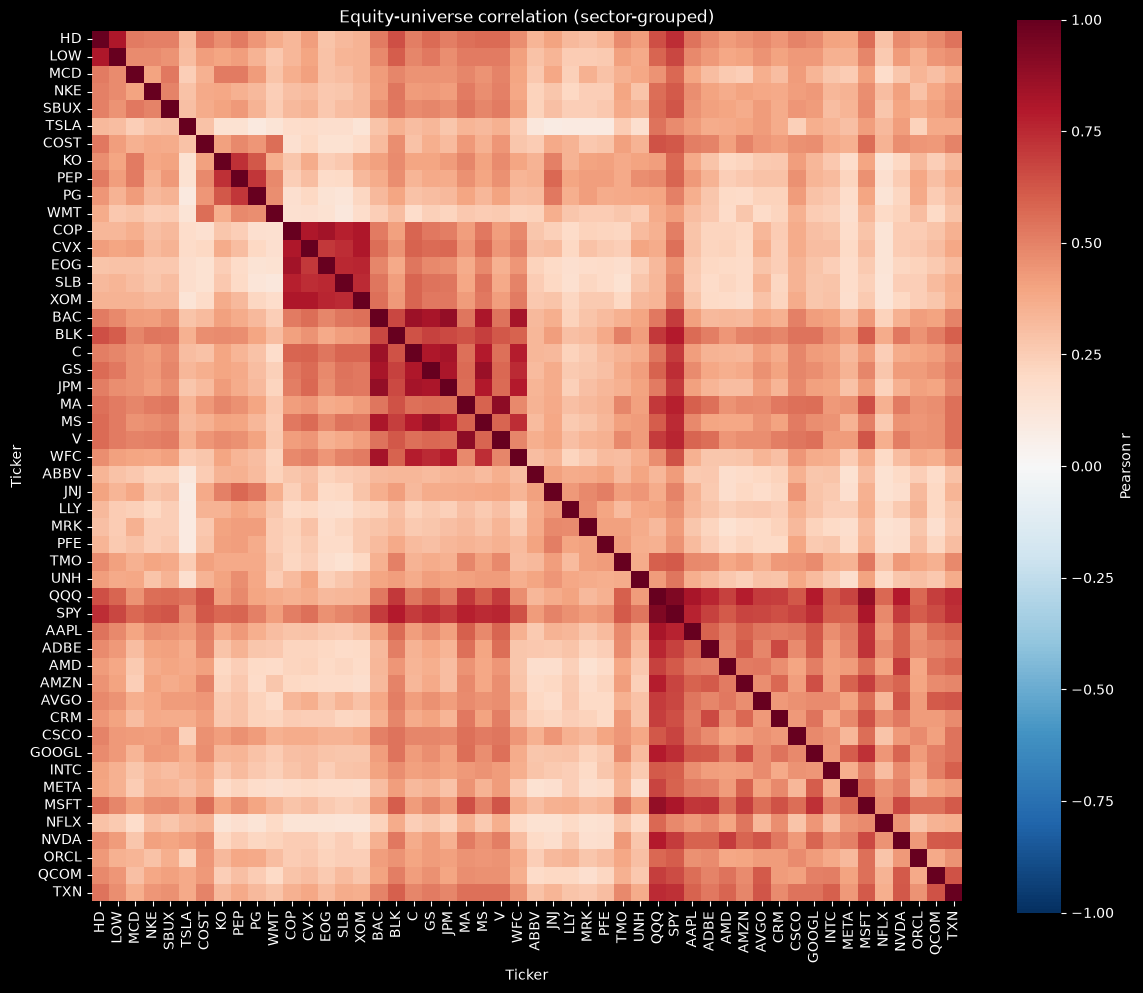

In [12]:
eq_returns = returns[EQUITIES].dropna(how="all")
corr = eq_returns.corr()
order = sorted(EQUITIES, key=lambda t: (TICKER_TO_SECTOR.get(t, "zz"), t))
corr = corr.reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Equity-universe correlation (sector-grouped)")
plt.tight_layout()
plt.savefig(REPORTS / "01_correlation_matrix.png", dpi=120)
plt.show()

## 12. Intra- vs inter-sector correlation & contagion

Intra-sector pairs should be more correlated than inter-sector pairs. We also
track the *rolling mean pairwise correlation* — it spikes toward 1.0 during
drawdowns ("everything sells off together"), the diversification-failure
phenomenon.

Intra-sector mean r: 0.536 (n=213)
Inter-sector mean r: 0.370 (n=1012)


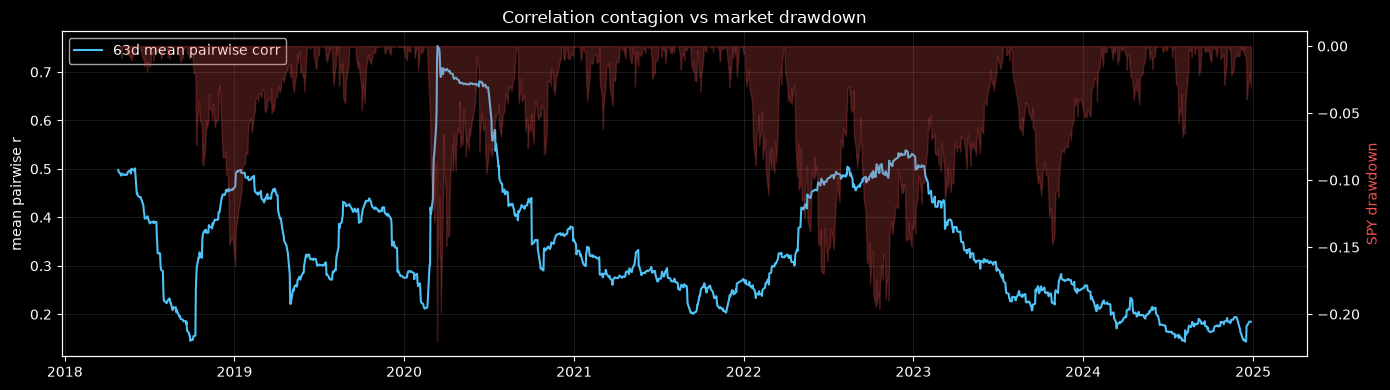

In [13]:
def sector(t):
    return TICKER_TO_SECTOR.get(t, "?")


intra, inter = [], []
for i, a in enumerate(EQUITIES):
    for b in EQUITIES[i + 1:]:
        r_ab = corr.loc[a, b]
        if pd.isna(r_ab):
            continue
        (intra if sector(a) == sector(b) else inter).append(r_ab)
print(f"Intra-sector mean r: {np.mean(intra):.3f} (n={len(intra)})")
print(f"Inter-sector mean r: {np.mean(inter):.3f} (n={len(inter)})")

# Rolling mean pairwise correlation vs SPY drawdown
win = 63
roll_corr = eq_returns.rolling(win).corr()
mean_pair = (roll_corr.groupby(level=0).apply(
    lambda m: (m.values[np.triu_indices_from(m.values, 1)]).mean()))
mean_pair = mean_pair.dropna()
spy_eq = (1 + returns["SPY"].reindex(mean_pair.index).fillna(0)).cumprod()
spy_dd = pd.Series(drawdown(spy_eq.to_numpy()), index=mean_pair.index)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mean_pair.index, mean_pair, color=COLORS["primary"], label="63d mean pairwise corr")
axb = ax.twinx()
axb.fill_between(spy_dd.index, spy_dd, 0, color=COLORS["danger"], alpha=0.25)
axb.set_ylabel("SPY drawdown", color=COLORS["danger"])
ax.set_ylabel("mean pairwise r"); ax.set_title("Correlation contagion vs market drawdown")
ax.legend(loc="upper left"); ax.grid(alpha=0.1)
plt.tight_layout()
plt.show()

## 13. PCA factor structure

The first principal component of equity returns is the *market factor*. Its
explained-variance share measures how "one-dimensional" the universe is, and
its loadings reveal which names move most with the market.

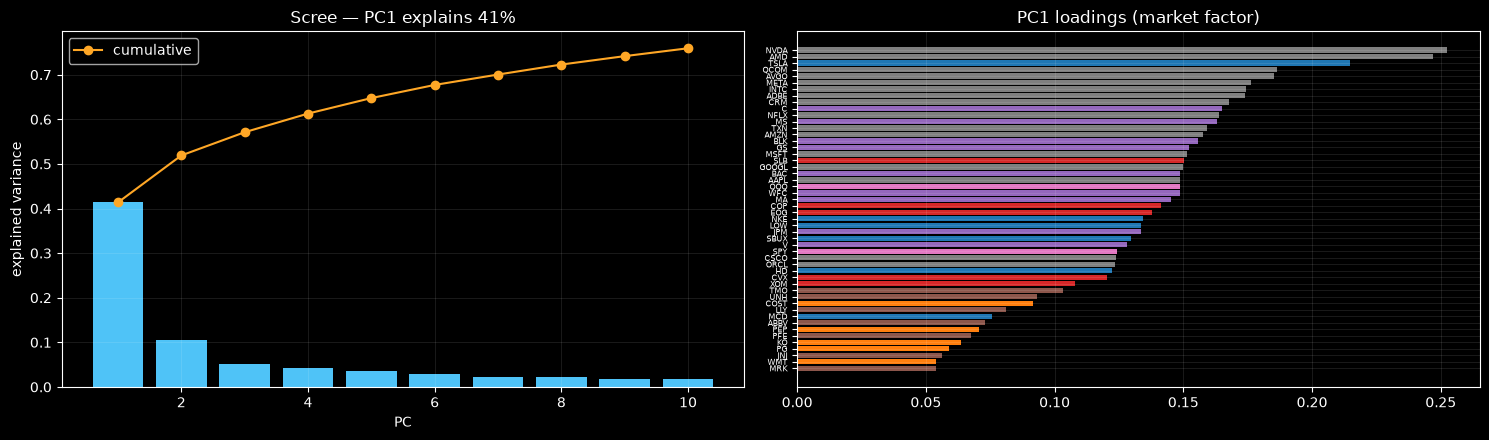

corr(PC1 score, SPY return) = +0.972


In [14]:
X = eq_returns.dropna()
pca = PCA(n_components=10).fit(X.values)
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(range(1, 11), evr, color=COLORS["primary"])
axes[0].plot(range(1, 11), np.cumsum(evr), "o-", color=COLORS["warning"], label="cumulative")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("explained variance")
axes[0].set_title(f"Scree — PC1 explains {evr[0]:.0%}"); axes[0].legend(); axes[0].grid(alpha=0.1)

pc1 = pd.Series(pca.components_[0], index=X.columns).sort_values()
colors = [SECTOR_PALETTE.get(TICKER_TO_SECTOR.get(t, "index"), "gray") for t in pc1.index]
axes[1].barh(range(len(pc1)), pc1.values, color=colors)
axes[1].set_yticks(range(len(pc1))); axes[1].set_yticklabels(pc1.index, fontsize=6)
axes[1].set_title("PC1 loadings (market factor)"); axes[1].grid(alpha=0.1)
plt.tight_layout()
plt.show()

market_factor = pd.Series(X.values @ pca.components_[0], index=X.index)
print(f"corr(PC1 score, SPY return) = {market_factor.corr(returns['SPY'].reindex(X.index)):+.3f}")

## 14. Liquidity — dollar volume & Amihud illiquidity

Amihud (2002) illiquidity = mean(|return| / dollar-volume): how much price moves
per dollar traded. High Amihud ⇒ thin, slippage-prone names the execution layer
must size down.

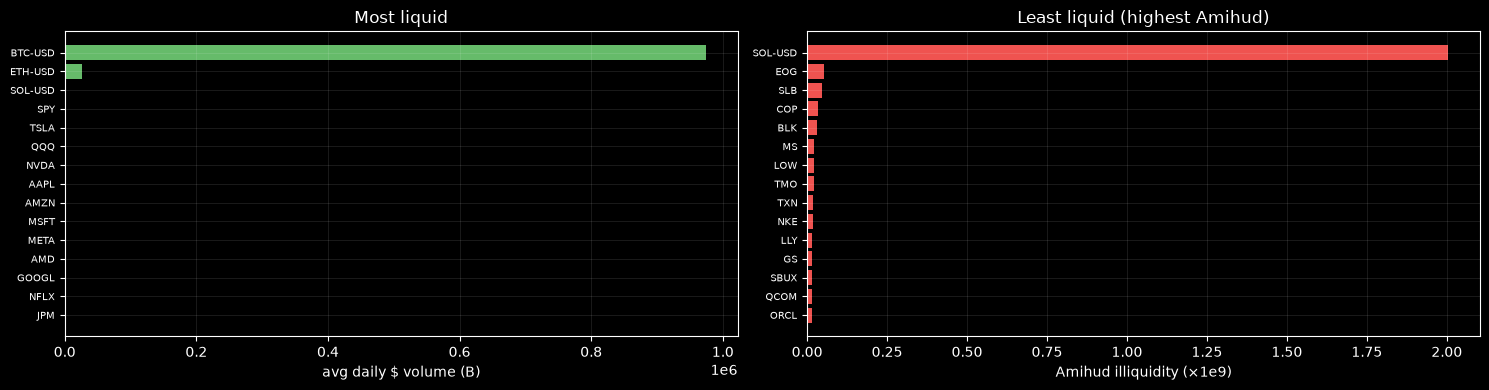

In [15]:
dollar_vol = (close * volume).mean()
amihud = {}
for t in UNIVERSE:
    dv = (close[t] * volume[t]).replace(0, np.nan)
    a = (returns[t].abs() / dv).replace([np.inf, -np.inf], np.nan).mean()
    if np.isfinite(a):
        amihud[t] = a * 1e9  # scaled for readability
amihud = pd.Series(amihud).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
dv_top = dollar_vol.sort_values(ascending=False).head(15)
axes[0].barh(range(len(dv_top)), dv_top.values / 1e9, color=COLORS["success"])
axes[0].set_yticks(range(len(dv_top))); axes[0].set_yticklabels(dv_top.index, fontsize=7)
axes[0].invert_yaxis(); axes[0].set_xlabel("avg daily $ volume (B)")
axes[0].set_title("Most liquid"); axes[0].grid(alpha=0.1)

il_top = amihud.head(15)
axes[1].barh(range(len(il_top)), il_top.values, color=COLORS["danger"])
axes[1].set_yticks(range(len(il_top))); axes[1].set_yticklabels(il_top.index, fontsize=7)
axes[1].invert_yaxis(); axes[1].set_xlabel("Amihud illiquidity (×1e9)")
axes[1].set_title("Least liquid (highest Amihud)"); axes[1].grid(alpha=0.1)
plt.tight_layout()
plt.show()

## 15. Intra-day frequency — TFT input resolutions (cached)

The TFT Temporal Encoder consumes 1m and 1h candles. yfinance limits: 1m (7d),
1h (730d). These windows are *relative to today*, so we cache the pull to keep
the notebook reproducible.

1m bars: 2730 | 1h bars: 5082


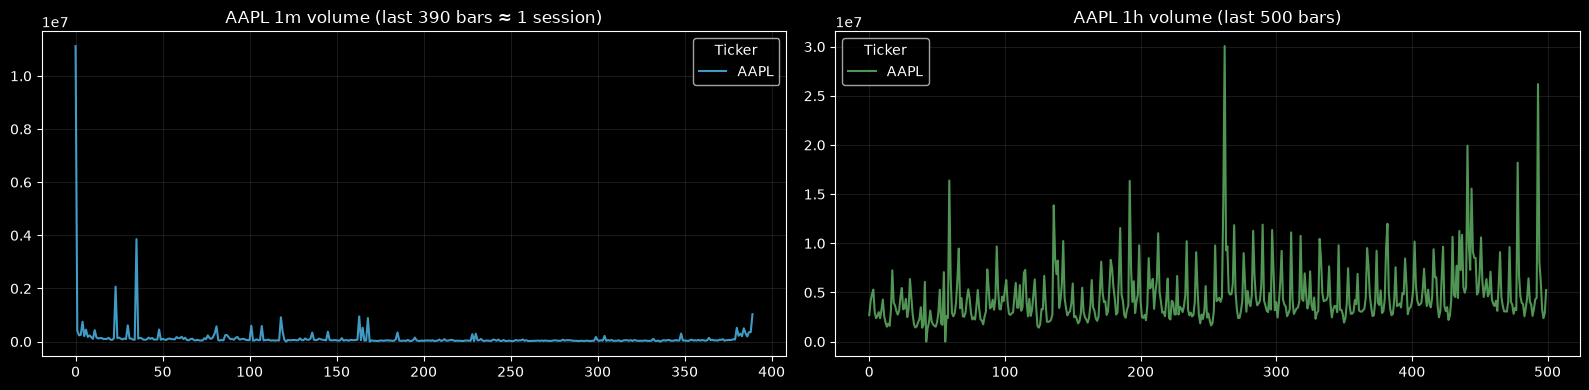

In [16]:
TICK = "AAPL"
intraday_1m = cached("intraday_1m_AAPL", lambda: yf.download(TICK, period="7d", interval="1m", progress=False))
intraday_1h = cached("intraday_1h_AAPL", lambda: yf.download(TICK, period="730d", interval="1h", progress=False))
print(f"1m bars: {len(intraday_1m)} | 1h bars: {len(intraday_1h)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
intraday_1m["Volume"].tail(390).reset_index(drop=True).plot(ax=axes[0], color=COLORS["primary"], alpha=0.8)
axes[0].set_title(f"{TICK} 1m volume (last 390 bars ≈ 1 session)")
intraday_1h["Volume"].tail(500).reset_index(drop=True).plot(ax=axes[1], color=COLORS["success"], alpha=0.8)
axes[1].set_title(f"{TICK} 1h volume (last 500 bars)")
for ax in axes:
    ax.grid(alpha=0.1)
plt.tight_layout()
plt.show()

## 16. Data-readiness scorecard

The checks are now driven by the *actual* universe size and a *per-calendar*
NaN audit, so a clean dataset genuinely passes.

In [17]:
def internal_nan_frac(df: pd.DataFrame) -> float:
    """Mean per-ticker NaN fraction *between* first and last valid bar.

    This is the correct data-quality measure: it ignores pre-inception gaps
    (e.g. SOL-USD listing in 2020) and counts only genuine mid-history holes.
    """
    fracs = []
    for t in df.columns:
        s = df[t]
        first, last = s.first_valid_index(), s.last_valid_index()
        if first is None:
            fracs.append(1.0)
        else:
            fracs.append(float(s.loc[first:last].isna().mean()))
    return float(np.mean(fracs))


# Each calendar is audited on its own trading days (equities skip weekends).
eq_cal = close[EQUITIES].dropna(how="all").index  # business days
eq_nan = internal_nan_frac(close[EQUITIES].reindex(eq_cal))
cr_nan = internal_nan_frac(close[CRYPTO]) if CRYPTO else 0.0
print(f"Internal NaN — equities: {eq_nan:.2%} | crypto: {cr_nan:.2%}")

checks = {
    "Daily OHLCV ≥ 3 years": len(close) >= 756,
    "1h intraday available": len(intraday_1h) > 0,
    "Equity NaN < 5% (own calendar)": eq_nan < 0.05,
    "Crypto NaN < 5% (own calendar)": cr_nan < 0.05,
    f"Universe size == {len(TARGET_TICKERS)}": len(UNIVERSE) == len(TARGET_TICKERS),
    "Intra-sector r > inter-sector r": np.mean(intra) > np.mean(inter),
    "Vol clustering present (LB p<0.01)": p_r2 < 0.01,
    "PC1 explains > 30% variance": evr[0] > 0.30,
}

print("=" * 60)
print("  DATA READINESS SCORECARD — Lumina V3 Chimera")
print("=" * 60)
all_pass = True
for name, ok in checks.items():
    print(f"    {'✅ PASS' if ok else '❌ FAIL'}  {name}")
    all_pass &= ok
print("=" * 60)
print(f"  Overall: {'READY TO PROCEED ✅' if all_pass else 'FIX ISSUES ABOVE ❌'}")
print("=" * 60)
assert all_pass, "Data readiness checks failed"

Internal NaN — equities: 0.00% | crypto: 0.00%
  DATA READINESS SCORECARD — Lumina V3 Chimera
    ✅ PASS  Daily OHLCV ≥ 3 years
    ✅ PASS  1h intraday available
    ✅ PASS  Equity NaN < 5% (own calendar)
    ✅ PASS  Crypto NaN < 5% (own calendar)
    ✅ PASS  Universe size == 53
    ✅ PASS  Intra-sector r > inter-sector r
    ✅ PASS  Vol clustering present (LB p<0.01)
    ✅ PASS  PC1 explains > 30% variance
  Overall: READY TO PROCEED ✅
